In [1]:
import sys
import os

sys.path.append('/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit')
sys.path.append('/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron')
sys.path.append('/home/paule/open_mc_projects/MC-1D_DT')

""

from src.geometry_classes import Geometry, Material, Neutron, Source, _BatchSource
import src.geometry_classes as geom
import src.performance_classes as perf
import src.tally_classes as tally
import src.vectfit as vf
import src.export_simulation_v3 as xpsim
import src.export_print_csv as xpcsv
import src.reconr_v2 as reconr
import src.parallel as parallel

import openmc

openmc.config['cross_sections'] = "/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/cross_sections.xml"





['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [2]:
# One slab of U238 — simple test case


# ============================================================================
# Uranium atom density
# ============================================================================
# Uranium metal density ~ 19.1 g/cm³,
# N = rho * Na / A  (atoms/cm³)
rho_U   = 19.1               # g/cm³
NA      = 6.02214076e23      # atoms/mol

x_U235 = 0.00                # 0% enrichment
x_U238 = 1.0 - x_U235

M_U8   = 238.05078826        # g/mol
M_U5   = 235.0439299         # g/mol
N_total_U8 = rho_U * NA / (x_U238 * M_U8 + x_U235 * M_U5)
N_total_U5 = rho_U * NA / (x_U235 * M_U5 + x_U238 * M_U8)

N_U235 = 1.0 * N_total_U5   # 0%  enrichment
N_U238 = 1.0 * N_total_U8   # 100%

slab1 = Material(
    name     = "cell 1",
    nuclides = [('U238', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U238', N_U238)],
    T        = 2000,     # K
)


('U238', 4.831863374901811e+22)
('U238', 4.831863374901811e+22)


In [6]:



# ============================================================================
# Geometry  (two slabs)
# ============================================================================
geom = Geometry(majorant_log=True, verbose=False)
geom.xs_dir = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/wmp'

geom.add_material(slab1)
geom.add_material(slab2)
geom.boundaries     = [0.0, 2.0, 15.0]  # cm
geom.material_array = [slab1, slab2]

# Flux tally: 5 energy groups
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
geom.attach_flux_tally(energy_bins)

# Verification tally: same energy bins, surface at slab1/slab2 interface
geom.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [2.0],        # slab1/slab2 interface
)

# Majorant and XS method
geom.maj_mat_method = "simple"  # majorant method: "maj_mat" 
geom.set_maj_xs_method(method="vectfit", T_array=[0, 293, 500, 1000, 1500, 1900, 2000], xs_maj_file_dir='src/vectfit_data')  # majorant XS method: "vectfit" 
geom.set_access_method("reconr", last_energy= 600, err_lim=0.0001, err_max=0.001)  # access method: "reconr" or "simple"
geom.set_mode("analysis", filename='validation/xs_generation/statepoint.200.h5')


# ============================================================================
# Source  (monoenergetic, at x=0, pointing right)
# ============================================================================
N_NEUTRONS  = 1000  # neutrons per batch
N_BATCHES   = 10    # number of independent batches (100 neutrons each)

src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = "mono",
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)




U238
U238
15.0
Building majorant XS grid for RECONR access method with settings:
xs_method:      vectfit
maj_mat_method: simple
materials:      ['cell 1', 'cell 2']
4309
600
 Evaluating the majorant cross section with RECONR stacking algorithm
err_lim = 0.0001, err_max = 0.001, err_int = 5e-09
last energy to add = 599.5985648781146 eV
number of windows = 4309
done
Second pass done — 9488 points
No inversions found in energy grid before dedup
Deduplication removed 0 points
Building O(1) Window Pointers...
Window pointer table: 747 windows
Final grid size:      9488 points
Window Pointers: [0, 110, 155, 178, 193, 203, 211, 217, 221, 225, 229, 232, 234, 236, 238, 240, 242, 244, 245, 246, 247, 248, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 309, 335, 339, 344, 345, 348, 349, 351, 353, 355, 358, 362, 366, 373, 381, 396, 439, 473, 498, 522, 5

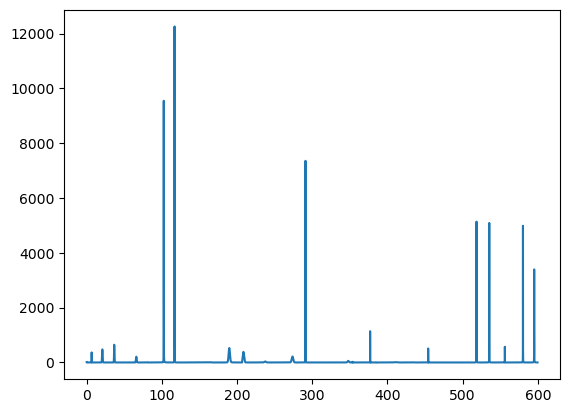

In [7]:
import matplotlib.pyplot as plt
plt.plot(geom.reconr_e_grid, geom.reconr_maj_xs_grid)

In [8]:
batch_stats = geom.run_source( src)
print(f"mode: {geom.mode}")
print(f"majorant XS method: {geom.maj_xs_method}")
print(f"majorant material method: {geom.maj_mat_method}")
print(f"access method: {geom.access_method}")
print(geom.summary())

#xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_reconr_v2_new.csv')



Running source with following setttings:
  Mode: analysis
  Majorant XS method: vectfit
  Material majorant method: simple
  Access method: reconr
mode: analysis
majorant XS method: vectfit
majorant material method: simple
access method: reconr
  SIMULATION SUMMARY
  Neutrons simulated      :      1,000
  Absorbed fraction       :    48.700%
  Leaked fraction         :    51.300%
------------------------------------------------------------
  Mean scatters/neutron   :       7.27
  Mean virtual/neutron    :       2.23
  Mean path length  [cm]  :    13.6318
------------------------------------------------------------
  MAJORANT XS DIAGNOSTICS
  Majorant updates        :      8,268
  Mean majorant [cm⁻¹]    :     0.9415
  Max  majorant [cm⁻¹]    :   106.2906
  Mean margin (maj/real)  :      1.242
  Min margin (maj/real)  :      1.000
  Max margin (maj/real)  :    130.813
  Most-limiting material  : cell 2
  Wrong majorant updates  :          1
  Wrong majorant mean error sum : 0.0000
  Wro

In [8]:
#xpsim.export_simulation(geom, batch_stats, print_to_console=False, save_csv=True, output_dir=f'simulation_output_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')
xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')


Cross-batch statistics saved → cross_batch_stats_group_simple_fly.csv


In [ ]:
print(slab1.nuclides)
print(slab1.total_density)

[(<openmc.data.multipole.WindowedMultipole object at 0x7d3514a68220>, 4.831863374901811e+22)]
4.831863374901811e+22


In [ ]:

# ============================================================================
# Materials
# ============================================================================
slab1 = Material(
    name     = "cell 1",
    nuclides = [('U238', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U238', N_U238)],
    T        = 2000,     # K
)

# ============================================================================
# Geometry  (two slabs)
# ============================================================================
geom = Geometry(majorant_log=True, verbose=False)
geom.xs_dir = '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/wmp'

geom.add_material(slab1)
geom.add_material(slab2)
geom.boundaries     = [0.0, 2.0, 15.0]  # cm
geom.material_array = [slab1, slab2]

# Flux tally: 5 energy groups
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
geom.attach_flux_tally(energy_bins)

# Verification tally: same energy bins, surface at slab1/slab2 interface
geom.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [2.0],        # slab1/slab2 interface
)

# Majorant and XS method
geom.set_mode("validation", filename='validation/xs_generation/statepoint.200.h5')
#geom.df_group_xs = df_cross_section

# ============================================================================
# Source  (monoenergetic, at x=0, pointing right)
# ============================================================================
N_NEUTRONS  = 100   # neutrons per batch
N_BATCHES   = 5    # number of independent batches (100 neutrons each)

src = Source(
    neutron_nbr  = N_NEUTRONS,
    energy_range = [500, 150],
    energy_dist  = "mono",
    position     = [0.0, 0.0, 0.0],
    direction    = [1.0, 0.0, 0.0],
)

print(geom.reconr_grid)



('U238', 4.831863374901811e+22)
('U238', 4.831863374901811e+22)
U238
U238
15.0
  Batch   1/5  (100 neutrons)  wall=1.036s
  Batch   2/5  (100 neutrons)  wall=1.142s
  Batch   3/5  (100 neutrons)  wall=0.976s
  Batch   4/5  (100 neutrons)  wall=1.003s
  Batch   5/5  (100 neutrons)  wall=0.991s

  CROSS-BATCH STATISTICS

  FLUX TALLY [cm · src-n⁻¹]
  Group                               Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  10-50 eV                      0.0000e+00     0.0000e+00        inf
  50-600 eV                     1.4127e+01     4.0099e-01     0.0284
  600-10000 eV                  0.0000e+00     0.0000e+00        inf
  10000-1000000 eV              0.0000e+00     0.0000e+00        inf
  1000000-20000000 eV           0.0000e+00     0.0000e+00        inf

  ABSORPTION RATE [reactions · src-n⁻¹]
  Region / Group                      Mean           ±Std    Rel.Err
  ---------------------------------------------------------

In [ ]:
# ============================================================================
# Run — batch mode
# ============================================================================
batch_stats = geom.run_batch(src, N_BATCHES)
xpcsv.export_cross_batch_stats(batch_stats, geom, print_to_console=True)
# ============================================================================
# Results
# ============================================================================
#print(geom.summary())


print(geom._nuclides_wmp_lib)
print(geom.nuclides)

{'U238': <openmc.data.multipole.WindowedMultipole object at 0x71305502adf0>}
{'U238': (<openmc.data.multipole.WindowedMultipole object at 0x71305502adf0>, 4.831863374901811e+22)}
